In [1]:
import os
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
from aqua.core.graphics import plot_single_map_diff, ConfigStyle
from aqua.core.logger import log_configure

In [2]:
# Import results from the biases_production.ipynb notebook, change accordingly to your machine
#folder = "/work/users/mnurisso/DestinE_paper/Figure4/netcdf"
folder = "/Users/mnurisso/src/DestinE_paper/Figure4/netcdf"

icon_file_mask = f"{folder}/*ICON*.nc"
ifs_nemo_file_mask = f"{folder}/*IFS-NEMO*.nc"
ifs_fesom_file_mask = f"{folder}/*IFS-FESOM*.nc"
era5_file_mask = f"{folder}/*ERA5*.nc"

icon_climatology = xr.open_mfdataset(icon_file_mask)
ifs_nemo_climatology = xr.open_mfdataset(ifs_nemo_file_mask)
ifs_fesom_climatology = xr.open_mfdataset(ifs_fesom_file_mask)
era5_climatology = xr.open_mfdataset(era5_file_mask)

In [3]:
var = 'u'
loglevel = 'INFO'
titles = ['ICON', 'IFS-NEMO', 'IFS-FESOM']
suptitle = "Global bias of zonal wind speed at 850 hPa (m/s) \n for o25.1 cycle historical runs \n with respect to ERA5 climatology (1990-2014)"
cbar_label = 'Zonal Wind Speed (m/s)'
panels_label = ['d)', 'e)', 'f)']

In [4]:
def plot_biases(models: list, ref: xr.DataArray, var: str,
                suptitle: str, titles: list,
                vmin_fill: float, vmax_fill: float,
                vmin_contour: float, vmax_contour: float,
                cbar_label: str, nlevels: int,
                cmap: str, 
                folder: str = './figures',
                norm: bool = False,
                panels_label: list = None,
                loglevel: str = 'INFO'):
    """
    Plot biases of different models with respect to a reference dataset.

    Args:
        models (list): List of model datasets.
        ref (xr.DataArray): Reference dataset.
        var (str): Variable to plot.
        suptitle (str): Super title for the figure.
        titles (list): Titles for each subplot.
        vmin_fill (float): Minimum value for fill color scale.
        vmax_fill (float): Maximum value for fill color scale.
        vmin_contour (float): Minimum value for contour color scale.
        vmax_contour (float): Maximum value for contour color scale.
        cbar_label (str): Colorbar label.
        nlevels (int): Number of contour levels.
        cmap (str): Colormap to use.
        folder (str): Folder to save the figure.
        norm (bool): Whether to normalize the data. Default is False.
        panels_label (list): Labels for each panel. If None, no labels are added.
        loglevel (str): Logging level.
    """
    # Set logger
    logger = log_configure(loglevel, 'plot_biases')

    # Configure AQUA plot style
    ConfigStyle(loglevel=loglevel)

    # Create figure
    nrows = len(models)
    ncols = 1
    figsize = (8, 4 * nrows)
    fig = plt.figure(figsize=figsize)

    levels = np.arange(vmin_fill, vmax_fill + 1, 1)

    if norm:
        # Replace exact zero with a small symmetric interval
        eps = 0.25
        levels = np.sort(np.unique(np.concatenate([
            levels[levels < 0],
            [-eps, eps],
            levels[levels > 0]
        ])))
        logger.debug(f"Levels for colormap: {levels}")
        cmap = plt.get_cmap(cmap)
        norm = BoundaryNorm(levels, cmap.N, clip=True)
    else:
        norm = None

    for i, model in enumerate(models, 1):
        data = model[var]

        logger.debug(f"Plotting {data}")

        fig, ax = plot_single_map_diff(
            data=data,
            data_ref=ref[var],
            fig=fig,
            norm=norm,
            ax_pos=(nrows, ncols, i),
            cmap=cmap, title=titles[i - 1],
            vmin_fill=vmin_fill, vmax_fill=vmax_fill,
            vmin_contour=vmin_contour, vmax_contour=vmax_contour,
            return_fig=True, cbar=False, sym=False,
            line_levels=6, nlevels=nlevels,
            title_size=14,
            loglevel=loglevel
        )

    # Adjust the location of the subplots on the page to make room for the colorbar
    fig.subplots_adjust(bottom=0.20, top=0.87, left=0.05, right=0.95,
                        wspace=0.1, hspace=0.2)

    # Add a colorbar axis at the bottom of the graph
    cbar_ax = fig.add_axes([0.2, 0.15, 0.6, 0.03])
    mappable = ax.collections[0]

    cbar = fig.colorbar(mappable, cax=cbar_ax, orientation='horizontal',
                        label=cbar_label)

    cbar.set_ticks(levels)
    cbar.ax.set_xticklabels([f'{tick:.0f}' if tick == int(tick) else f'{tick:.1f}' for tick in levels])
    cbar.ax.tick_params(labelsize=9)

    #fig.suptitle(suptitle, fontsize=15)

    for i in range(len(models)):
        if panels_label is not None:
            ax = fig.axes[i]
            ax.text(0.02, 0.95, panels_label[i], transform=ax.transAxes,
                    fontsize=12, fontweight='bold', va='top', ha='left')

    # Save figure
    output_file = f"{folder}/zonal_wind_speed_850hPa_biases.pdf"

    # Be sure the folder exists
    os.makedirs(folder, exist_ok=True)
    fig.savefig(output_file)
    logger.info(f"Figure saved to {output_file}")

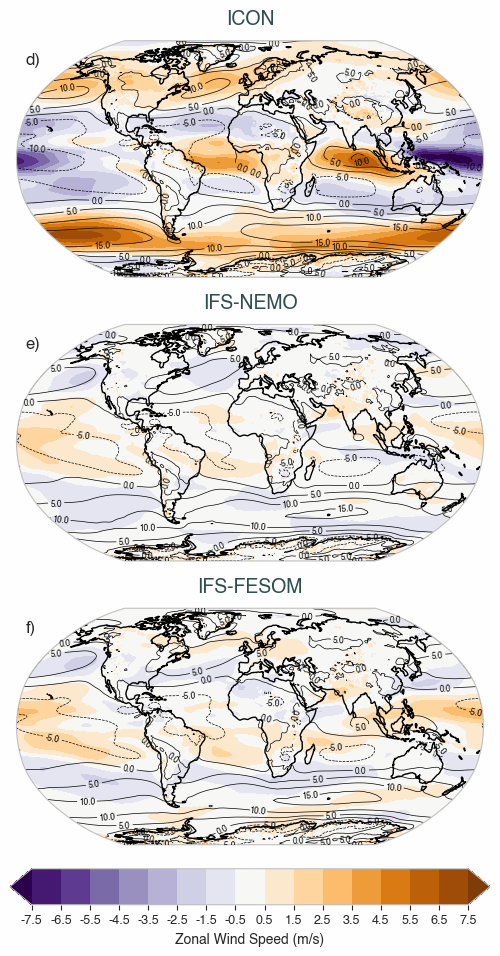

In [5]:
plot_biases(
    models=[icon_climatology, ifs_nemo_climatology, ifs_fesom_climatology],
    ref=era5_climatology,
    var=var,
    vmin_fill=-7.5,
    vmax_fill=7.5,
    vmin_contour=-10.0,
    vmax_contour=15.0,
    cmap='PuOr_r',
    titles=titles,
    suptitle=suptitle,
    cbar_label=cbar_label,
    nlevels=15,
    norm=False,
    panels_label=panels_label,
    loglevel='WARNING'
)